In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_results(csv_path):
    sns.set_theme(style="whitegrid")
    
    # 1. Load the data from CSV
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File {csv_path} not found.")
        return

    # Check if required columns exist
    required_cols = ['epoch', 'train_loss', 'eval_loss', 'eval_top1', 'eval_top5']
    if not all(col in df.columns for col in required_cols):
        print(f"Error: CSV must contain {required_cols}")
        return

    # 2. Create the figure and subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Model Training Metrics', fontsize=16, fontweight='bold')

    # --- Subplot 1: Loss Curves ---
    # 绘制训练损失和验证损失曲线
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
    ax1.plot(df['epoch'], df['eval_loss'], label='Eval Loss', color='#ff7f0e', linewidth=2, linestyle='--', marker='s', markersize=4)
    
    ax1.set_title('Training and Evaluation Loss', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(frameon=True)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- Subplot 2: Accuracy Curves ---
    # 绘制 Top-1 和 Top-5 精度曲线
    ax2.plot(df['epoch'], df['eval_top1'], label='Top-1 Accuracy', color='#2ca02c', linewidth=2, marker='^', markersize=5)
    ax2.plot(df['epoch'], df['eval_top5'], label='Top-5 Accuracy', color='#d62728', linewidth=2, marker='v', markersize=5)
    
    ax2.set_title('Evaluation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(loc='lower right', frameon=True)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # 3. Optional: Add Learning Rate on a twin axis in Subplot 1
    # 可选：在 Loss 图中添加学习率曲线（使用右侧 Y 轴）
    if 'lr' in df.columns:
        ax1_lr = ax1.twinx()
        ax1_lr.plot(df['epoch'], df['lr'], color='gray', alpha=0.3, label='LR')
        ax1_lr.set_ylabel('Learning Rate', color='gray', fontsize=10)
        ax1_lr.tick_params(axis='y', labelcolor='gray')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plt.savefig('training_curves.png', dpi=300)
    print("Plot saved as 'training_curves.png'")
    plt.show()

In [ ]:
plot_training_results('/home/chenzhiqiang/MaskLLM-4V/output/sparse_deit_small_patch16_224_90_epochs_lr1e-3_.augreg_in1k.hybird/HybirdSparse/summary.csv')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
tp_values = [24, 28, 32, 36, 40]
acc_30epochs = [77.41, 77.27, 77.23, 76.98, 76.72]
acc_90epochs = [77.59, 77.53, 77.47, 77.06, 77.02]
baseline_acc = 77.74  # Dense 模型精度基线

# 创建图形（使用更现代的样式）
plt.figure(figsize=(11, 7))
plt.style.use('seaborn-v0_8-whitegrid')  # 清爽背景 + 网格

# 绘制 Dense 模型基线（突出显示）
plt.axhline(y=baseline_acc, color='#2ca02c', linestyle='--', linewidth=2.8,
            label=f'Step 1 Sparse Model (Baseline: {baseline_acc:.1f}%)', alpha=0.9)
# 基线右侧标注（带背景框）
plt.text(tp_values[-1] + 1.5, baseline_acc + 0.08, f'{baseline_acc:.1f}%',
         fontsize=11, fontweight='bold', color='#2ca02c',
         bbox=dict(facecolor='white', edgecolor='#2ca02c', alpha=0.85, boxstyle='round,pad=0.4'))

# 绘制训练曲线（优化颜色与标记）
plt.plot(tp_values, acc_30epochs,
         marker='o', linewidth=2.6, markersize=9, markeredgewidth=1.5,
         label='30 Epochs', color='#1f77b4', markeredgecolor='white', alpha=0.95)
plt.plot(tp_values, acc_90epochs,
         marker='D', linewidth=2.6, markersize=9, markeredgewidth=1.5,
         label='90 Epochs', color='#ff7f0e', markeredgecolor='white', alpha=0.95)

# 坐标轴与标题（增强专业感）
plt.xlabel('Token Pruning Number (TP)', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Classification Accuracy (%)', fontsize=13, fontweight='bold', labelpad=10)
plt.title('Impact of Token Pruning on Classification Accuracy\n'
          f'(Step 1 Sparse Model Baseline: {baseline_acc:.1f}%)',
          fontsize=15, fontweight='bold', pad=20, loc='center')

# 图例（右下角，避免遮挡曲线与基线）
plt.legend(loc='lower right', fontsize=11.5, frameon=True, shadow=True,
           fancybox=True, borderpad=0.8, handlelength=2.2)

# 网格与坐标轴优化
plt.grid(True, linestyle='--', alpha=0.65, linewidth=0.9, which='both')
plt.xticks(tp_values, fontsize=11)
plt.yticks(np.arange(76.0, 80.1, 0.5), fontsize=11)
plt.ylim(76.5, 78.0)  # 留出基线上方空间
plt.xlim(22, 42)      # 横轴微扩，避免点贴边

# 数据标签（智能偏移，避免重叠）
for i, (x, y) in enumerate(zip(tp_values, acc_30epochs)):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9, color='#1f77b4', fontweight='bold')
for i, (x, y) in enumerate(zip(tp_values, acc_90epochs)):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, -14),
                 ha='center', fontsize=9, color='#ff7f0e', fontweight='bold')

# 紧凑布局 + 边距优化
plt.tight_layout(pad=2.0)

# 保存与显示（取消注释可保存高清图）
# plt.savefig('token_pruning_accuracy_with_baseline.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# Plot DSE Figure

Total workloads to evaluate: 24
BxRxC      | Util(L/D/B)        | Freq   | Cycles     | Energy     | EDP        | Bottle
--------------------------------------------------------------------------------------------
2x4x4      | 0.04/0.01/0.07     | 399    | 32473820   | 110984.1   | 3.60e+12   | Compute
2x4x8      | 0.07/0.03/0.12     | 398    | 17460008   | 72555.1    | 1.27e+12   | Compute
2x4x12     | 0.10/0.04/0.16     | 397    | 12662227   | 60706.9    | 7.69e+11   | Compute
2x4x16     | 0.13/0.05/0.20     | 396    | 10397412   | 55470.4    | 5.77e+11   | Compute
2x4x20     | 0.16/0.06/0.25     | 395    | 9167571    | 53144.8    | 4.87e+11   | Compute
2x4x24     | 0.18/0.08/0.29     | 393    | 8307895    | 51584.7    | 4.29e+11   | Compute
2x4x28     | 0.21/0.09/0.34     | 392    | 7642835    | 50510.4    | 3.86e+11   | Compute
2x4x32     | 0.24/0.10/0.38     | 390    | 6934123    | 48681.5    | 3.38e+11   | Compute
2x4x36     | 0.27/0.11/0.42     | 388    | 6444794    | 47835.7   

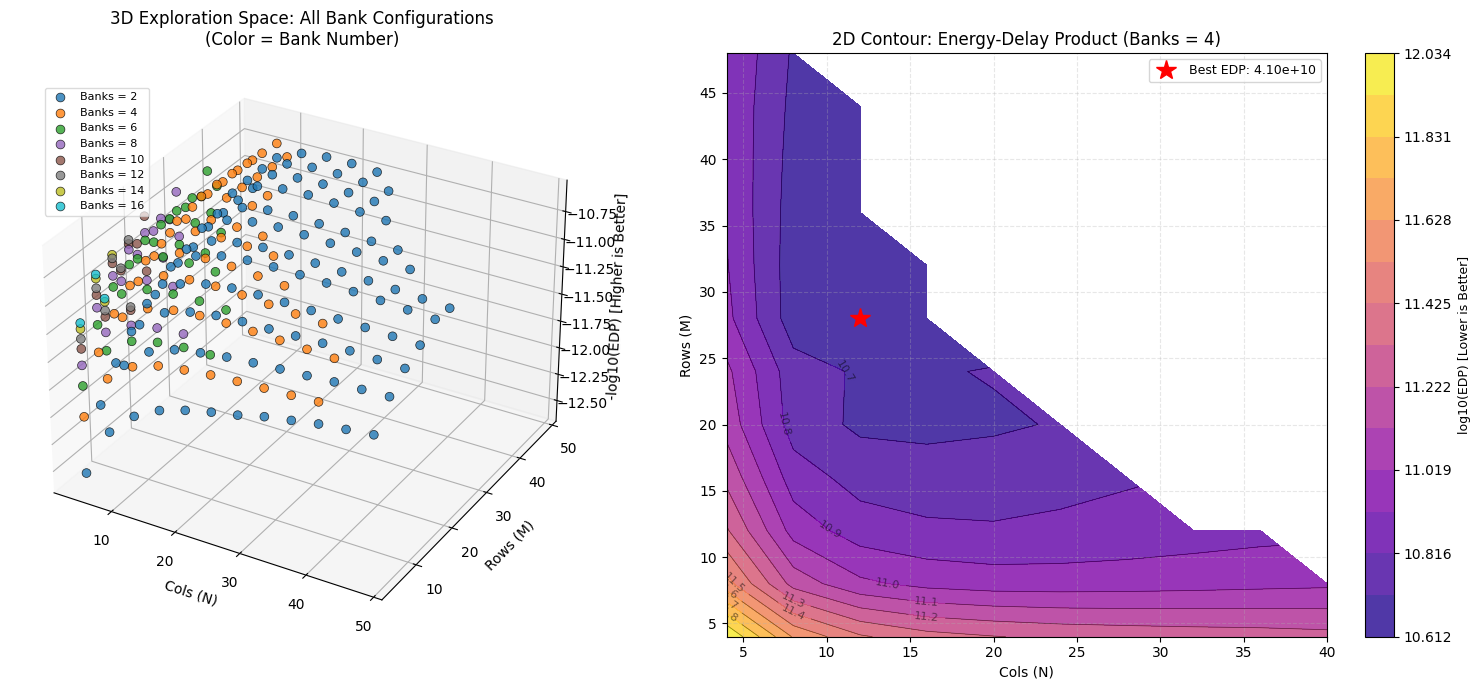

In [1]:
from dse.flexsparse_dse_v2 import *

# 扩展 get_deit_small_workload，为每个层生成所有稀疏度模式
def get_deit_small_workload_all_sparsity() -> List[WorkloadConfig]:
    model_layers = {
        "qkv_proj": MatrixConfig(M=197, K=384, N=1152),
        "o_proj": MatrixConfig(M=197, K=384, N=384),
        "matmul1": MatrixConfig(M=197, K=64, N=197, Head=6),
        "matmul2": MatrixConfig(M=197, K=64, N=197, Head=6),
        "fc1": MatrixConfig(M=197, K=1536, N=384),
        "fc2": MatrixConfig(M=197, K=384, N=1536),
    }
    all_sparsity_modes = [
        SparsityMode.SPARSE_1_4,
        SparsityMode.SPARSE_2_4,
        SparsityMode.SPARSE_3_4,
        SparsityMode.SPARSE_4_4,
    ]
    workloads = []
    for layer_name, mat_cfg in model_layers.items():
        for sp_mode in all_sparsity_modes:
            workloads.append(WorkloadConfig(
                layer_name=layer_name,
                input_m=mat_cfg.M,
                input_n=mat_cfg.N,
                input_k=mat_cfg.K,
                input_head=mat_cfg.Head,
                sparse_mode=sp_mode
            ))
    return workloads


all_workloads = get_deit_small_workload_all_sparsity()
print(f"Total workloads to evaluate: {len(all_workloads)}")
run_dse_flexsparse_target_model(all_workloads)


In [ ]:
plot_roofline_relationship()

## Calculate Cycles

In [ ]:
import pickle

with open("./deit_small_layerwise_importance_20251223.pkl", "rb") as f:
    temp = pickle.load(f)

In [ ]:
print(temp)

In [ ]:
import random
from typing import Union, Tuple, Dict, List


ROWS = 32          # _ROWS
COLS = 32          # _COLS
SPARSE_M = 4       # number of elements per sparse block (mask width = 2 bits)

PERTURB_CONFIG = {
    'enable': True,                # enable/disable perturbation
    'random_seed': 42,             # fixed seed for reproducibility
    'fixed_overhead_cycles': 100,  # constant cycles added per matmul
    'data_overhead_per_element': 0.01,  # cycles per element (read+write)
    'noise_percent_range': (-5, 15),    # uniform percent range added as noise
}

# ----------------------------------------------------------------------
# Mapping from user sparsity spec to hardware configuration
# ----------------------------------------------------------------------
def _sparsity_to_hw(sparsity: Union[int, str]) -> Tuple[int, int, bool]:
    """Convert user sparsity to (cfg_sparse_n, max_cycles, is_dense)."""
    if sparsity == 'dense' or sparsity == 3:
        return 3, 1, True
    if sparsity == 1:
        return 0, 1, False
    elif sparsity == 2:
        return 1, 2, False
    elif sparsity == 3:
        return 2, 3, False
    else:
        raise ValueError(f"Invalid sparsity value: {sparsity}")

# ----------------------------------------------------------------------
# Perturbation function
# ----------------------------------------------------------------------
def apply_perturbation(theoretical_cycles: int, M: int, N: int, K: int, config: Dict) -> int:
    """
    Add simulated overheads to theoretical cycles.
    config: dictionary containing perturbation parameters.
    Returns perturbed cycle count (rounded to integer, at least theoretical_cycles).
    """
    if not config.get('enable', False):
        return theoretical_cycles

    # 1. Fixed overhead
    total = theoretical_cycles + config.get('fixed_overhead_cycles', 0)

    # 2. Data transfer overhead: each element read or written contributes a small cycle cost
    #   - Input A: M*K, Input B: K*N, Output C: M*N
    total_elements = M*K + K*N + M*N
    data_overhead = total_elements * config.get('data_overhead_per_element', 0.0)
    total += int(data_overhead)

    # 3. Random multiplicative noise (percentage)
    low, high = config.get('noise_percent_range', (0, 0))
    if low != 0 or high != 0:
        # Convert percent to factor: e.g., -5% -> 0.95, +15% -> 1.15
        factor = 1.0 + random.uniform(low / 100.0, high / 100.0)
        total = total * factor

    # Ensure we never return fewer cycles than the theoretical minimum
    return max(theoretical_cycles, int(round(total)))

# ----------------------------------------------------------------------
# Core cycle count formula for one matrix multiplication (with optional perturbation)
# ----------------------------------------------------------------------
def cycles_for_matmul(M: int, N: int, K: int, sparsity: Union[int, str]) -> int:
    """
    Compute theoretical cycles, then apply perturbation.
    """
    cfg, max_cycles, is_dense = _sparsity_to_hw(sparsity)

    M_blocks = math.ceil(M / ROWS)
    N_blocks = math.ceil(N / COLS)

    if is_dense:
        reps = K
    else:
        reps = math.ceil(K / SPARSE_M)

    skew_size = (ROWS + COLS - 1) * max_cycles
    cycles_per_block = max_cycles * (reps + skew_size)
    theoretical = M_blocks * N_blocks * cycles_per_block
    print("Sparsity:", sparsity, M_blocks, N_blocks, cycles_per_block)

    # Apply perturbation (simulate non-linear & data transfer overhead)
    perturbed = apply_perturbation(theoretical, M, N, K, PERTURB_CONFIG)
    return perturbed

# ----------------------------------------------------------------------
# DeiT‑Small model dimensions (with token pruning)
# ----------------------------------------------------------------------
INIT_SEQ_LEN = 197
HIDDEN_DIM = 384
MLP_DIM = 1536
NUM_HEADS = 6
HEAD_DIM = HIDDEN_DIM // NUM_HEADS

# Matrix multiplication definitions for one Transformer block
BLOCK_OPS = [
    ("attn.qkv",        lambda s: s,                         # M = seq_len
                        lambda s: 3 * HIDDEN_DIM,            # N = 3 * hidden_dim
                        lambda s: HIDDEN_DIM,                # K = hidden_dim
                        None),
    ("attn.matmul1",    lambda s: s,                         # M = seq_len
                        lambda s: s,                         # N = seq_len
                        lambda s: HIDDEN_DIM,                # K = hidden_dim
                        'dense'),
    ("attn.matmul2",    lambda s: s,                         # M = seq_len
                        lambda s: HIDDEN_DIM,                # N = hidden_dim
                        lambda s: s,                         # K = seq_len
                        'dense'),
    ("attn.proj",       lambda s: s,
                        lambda s: HIDDEN_DIM,
                        lambda s: HIDDEN_DIM,
                        None),
    ("mlp.fc1",         lambda s: s,
                        lambda s: MLP_DIM,
                        lambda s: HIDDEN_DIM,
                        None),
    ("mlp.fc2",         lambda s: s,
                        lambda s: HIDDEN_DIM,
                        lambda s: MLP_DIM,
                        None),
]

# ----------------------------------------------------------------------
# Token pruning: at layers 3, 6, 9 (1‑indexed) remove 32 tokens each
# ----------------------------------------------------------------------
PRUNE_BLOCKS = [3, 6, 9]
PRUNE_TOKENS = 32

def get_sequence_lengths(num_blocks: int) -> List[int]:
    """Return list of sequence lengths for each block (0‑indexed)."""
    seq_lens = []
    cur_len = INIT_SEQ_LEN
    for blk_idx in range(num_blocks):
        if (blk_idx) in PRUNE_BLOCKS:
            cur_len -= PRUNE_TOKENS
        seq_lens.append(cur_len)
    return seq_lens

# ----------------------------------------------------------------------
# Compute cycles for all layers with sparsity and pruning
# ----------------------------------------------------------------------
def compute_deit_cycles(layer_sparsity: Dict[str, Union[int, str]]) -> Dict[str, int]:
    """
    layer_sparsity: mapping "block<i>_<op>" -> sparsity (1,2,3,'dense')
    Returns dictionary with final (perturbed) cycle counts.
    """
    # Initialize random seed for reproducibility
    if PERTURB_CONFIG.get('enable', False):
        random.seed(PERTURB_CONFIG.get('random_seed', 42))

    num_blocks = 12
    seq_lens = get_sequence_lengths(num_blocks)
    results = {}

    for blk_idx in range(num_blocks):
        cur_seq = seq_lens[blk_idx]

        for op_name, m_func, n_func, k_func, default_sp in BLOCK_OPS:
            # blocks.0.attn.proj
            full_name = f"blocks.{blk_idx}.{op_name}"

            if op_name in ["attn_matmul1", "attn_matmul2"]:
                sp = 'dense'
            else:
                sp = layer_sparsity.get(full_name, default_sp)
                if sp is None:
                    sp = 'dense'

            M = m_func(cur_seq)
            N = n_func(cur_seq)
            K = k_func(cur_seq)

            cycles = cycles_for_matmul(M, N, K, sp)
            results[full_name] = cycles

    return results


In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Assume these functions are defined elsewhere
cycles_per_op = compute_deit_cycles(temp)
seq_lens = get_sequence_lengths(12)

print("Theoretical cycle counts for each matrix multiplication in DeiT-Small")
print("with token pruning at layers 3, 6, 9 (32 tokens removed each time):\n")

total_cycles = 0
for name, cycles in cycles_per_op.items():
    print(f"{name:30} : {cycles:12,} cycles")
    total_cycles += cycles

print("\n" + "="*60)
print(f"TOTAL CYCLES FOR ONE FORWARD PASS: {total_cycles:,}")

# --- Group cycles by block index (0..11) ---
block_cycles = {}          # key: block index (int), value: total cycles in that block
for name, cycles in cycles_per_op.items():
    # Extract block index from key, e.g., "blocks.0.mlp.fc1" -> 0
    parts = name.split('.')
    if parts[0] == 'blocks' and parts[1].isdigit():
        blk_idx = int(parts[1])
        block_cycles[blk_idx] = block_cycles.get(blk_idx, 0) + cycles

# Get sequence lengths for each block (after pruning)
seq_lens = get_sequence_lengths(12)   # returns list of length 12

# --- Print cycles per block with sequence length ---
print("\nCycles per block (sequence length shown in parentheses):")
for blk_idx in range(12):
    cyc = block_cycles.get(blk_idx, 0)
    print(f"  blocks.{blk_idx:2d} (seq_len={seq_lens[blk_idx]:3d}) : {cyc:12,} cycles")

# --- Bar chart: cycles per block ---
plt.style.use('seaborn-v0_8-whitegrid')   # clean, modern look
fig, ax = plt.subplots(figsize=(10, 6))

blocks = list(range(12))
cycles_vals = [block_cycles.get(i, 0) for i in blocks]

bars = ax.bar(blocks, cycles_vals, color='steelblue', edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01*max(cycles_vals),
            f'{int(height):,}', ha='center', va='bottom', fontsize=9, rotation=0)

# Annotate each bar with its sequence length (small text below x-tick)
# for i, (blk, seq) in enumerate(zip(blocks, seq_lens)):
#     ax.text(blk, -0.05 * max(cycles_vals), f'len={seq}', ha='center', va='top',
#             fontsize=8, color='gray', rotation=0)

# Labels and title
ax.set_xlabel('Block Index', fontsize=12)
ax.set_ylabel('Theoretical Cycle Count', fontsize=12)
ax.set_title('DeiT-Small: Cycle Count per Block (with Token Pruning at layers 3,6,9)',
             fontsize=14, fontweight='semibold')
ax.set_xticks(blocks)
ax.set_xticklabels(blocks)

# Optional: add a grid only on y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Adjust layout to prevent clipping of text
plt.tight_layout()

# Show the plot (if running interactively) or save to file
plt.show()